# Hybrid AI-Based Garment Defect Detection System Using YOLOv11 and OpenCV

## Overview

This notebook presents the implementation of a hybrid garment defect
inspection system for detecting missing buttons and misaligned buttons
on shirts.

The proposed approach combines the object detection capabilities of
YOLOv11 with OpenCV-based geometric verification to improve detection
reliability under varying lighting conditions, shirt fabrics and camera
positions.

Unlike conventional image classification methods, the proposed system
identifies the exact location of garment defects before verifying the
spatial arrangement of buttons using computer vision techniques.

The workflow consists of four major stages:

1. Dataset Preparation
2. YOLOv11 Training
3. OpenCV Geometric Verification
4. Hybrid Decision Making

# Project Objectives

The objectives of this project are:

• Detect normal shirt buttons using YOLOv11.

• Detect missing buttons using YOLOv11.

• Detect misaligned buttons using YOLOv11.

• Verify detected button locations using OpenCV geometric analysis.

• Measure button alignment based on the spatial distribution of button centres.

• Improve the reliability of garment defect inspection through a hybrid AI and Computer Vision framework.

• Evaluate the proposed model using object detection performance metrics including Precision, Recall, F1-score and Mean Average Precision (mAP).

# Dataset Description

The dataset consists of annotated front-view shirt images containing three object classes.

## Classes

• button

Represents a correctly aligned shirt button.

• missing_button

Represents the expected location of a missing button.

• misaligned_button

Represents a button that is stitched in an incorrect position.

The dataset is organised according to the Ultralytics YOLO dataset format and contains separate folders for training, validation and testing.

# 1. Mount Google Drive

## Purpose

This notebook is developed in **Google Colab**, where the training dataset,
trained models, prediction results and evaluation outputs are stored in
Google Drive.

Mounting Google Drive allows Colab to directly access these files and
save outputs without losing them when the runtime disconnects.

In [3]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

print(os.listdir('/content/drive/MyDrive'))

['IMG-20240305-WA0061.jpg', 'Parami Ashinsa CV.pdf', 'IMG-20240317-WA0012.jpg', 'YTVIDS', 'New Text Document.txt', 'MagneticMind', '2.png', 'A tiny little bird.pdf', 'Classroom', 'IMG_20250628_123414.jpg', 'CameraRenting.gsheet', 'ToDoList.gsheet', 'GPA_Calculator.gsheet', 'ProjectProposal.gdoc', 'Colab Notebooks', 'PermissionRequestLetter_Brandix.docx', 'PermissionRequestLetter_Brandix.gdoc', 'Photoshop ', 'Photoshoot ', 'Movie', 'ParamiAshinsa-Portfolio.gsite', 'ImagesFromPhone', 'Dataset_GarmentDefectDetection']


In [8]:
!find "/content/drive/MyDrive/Dataset_GarmentDefectDetection" -maxdepth 3

/content/drive/MyDrive/Dataset_GarmentDefectDetection


# 2. Set Working Directory

## Purpose

To simplify file management, the project folder stored in Google Drive is
set as the current working directory.

All datasets, trained models, predictions and results generated throughout
this notebook will be accessed relative to this directory.

In [4]:
# ============================================================
# Set Project Directory
# ============================================================

import os

# Change this path to your project folder
PROJECT_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons"
os.chdir(PROJECT_PATH)

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/content/drive/.shortcut-targets-by-id/1E4kvBJ5Lslr85W16KJjc1gyJWqVDDCqk/Dataset_GarmentDefectDetection/YoloModelDataset/MissingButtons


# 3. Install Required Libraries

## Purpose

This project requires several Python libraries for deep learning,
computer vision and data visualisation.

The primary object detection framework used is **Ultralytics YOLOv11**,
while **OpenCV** is used for image processing and geometric verification.

In [7]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q ultralytics

print("Libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
Libraries installed successfully.


# 4. Import Required Libraries

## Purpose

Import all required Python packages that will be used throughout the
implementation of the hybrid garment defect detection system.

In [8]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import glob
import random
import warnings

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


# 5. Verify GPU Availability

## Purpose

Training a deep learning model is computationally intensive.
Google Colab provides access to NVIDIA GPUs, which significantly reduce
training time.

This section verifies that a GPU is available before training begins.

In [12]:
# ============================================================
# Check GPU
# ============================================================

import torch

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name :", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Enable GPU in Runtime > Change runtime type.")

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Name : Tesla T4


# 6. Verify Dataset Structure

## Purpose

Before training the YOLOv11 model, it is important to verify that the
dataset has been organised correctly according to the Ultralytics YOLO
format.

The expected directory structure is:

dataset/
│
├── train/
│   ├── images/
│   └── labels/
│
├── valid/
│   ├── images/
│   └── labels/
│
├── test/
│   ├── images/
│   └── labels/
│
└── data.yaml

This section checks whether all required folders and files exist before
training begins.

In [5]:
# ============================================================
# Verify Dataset Structure
# ============================================================

import os

# Path to YOLO dataset
DATASET_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset"

print("=" * 60)
print("Dataset Verification")
print("=" * 60)

required_paths = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels"
]

for path in required_paths:
    full_path = os.path.join(DATASET_PATH, path)

    if os.path.exists(full_path):
        print(f"✅ {path}")
    else:
        print(f"❌ Missing : {path}")

print("\nVerification Complete.")

Dataset Verification
✅ train/images
✅ train/labels
✅ valid/images
✅ valid/labels
✅ test/images
✅ test/labels

Verification Complete.


# 7. Read Dataset Configuration

## Purpose

Ultralytics YOLO stores dataset information inside the **data.yaml**
configuration file.

This file specifies:

- Dataset location
- Training images
- Validation images
- Test images
- Class names
- Number of object classes

Reading this file verifies that the dataset configuration is correct
before model training.

In [14]:
# ============================================================
# Read data.yaml
# ============================================================

import yaml

yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as file:
    data_yaml = yaml.safe_load(file)

print("=" * 60)
print("YOLO Dataset Configuration")
print("=" * 60)

for key, value in data_yaml.items():
    print(f"{key} : {value}")

YOLO Dataset Configuration
path : /content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset
train : train/images
val : valid/images
test : test/images
nc : 3
names : ['button_misaligned', 'buttons', 'missing_button_gap']


# 8. Dataset Statistics

## Purpose

Understanding the number of images available for training, validation,
and testing helps verify that the dataset has been split correctly.

This section counts the number of images contained in each subset.

In [15]:
# ============================================================
# Count Dataset Images
# ============================================================

import glob

train_images = glob.glob(os.path.join(DATASET_PATH, "train/images/*"))
valid_images = glob.glob(os.path.join(DATASET_PATH, "valid/images/*"))
test_images = glob.glob(os.path.join(DATASET_PATH, "test/images/*"))

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(valid_images)}")
print(f"Testing Images    : {len(test_images)}")
print(f"Total Images      : {len(train_images)+len(valid_images)+len(test_images)}")

Dataset Statistics
Training Images   : 3216
Validation Images : 115
Testing Images    : 115
Total Images      : 3446


# 9. Visualize Sample Images

## Purpose

Visual inspection of the dataset is an important preprocessing step.

This section randomly selects sample images from the training dataset to
verify image quality, orientation, lighting conditions, and overall
dataset diversity before training.

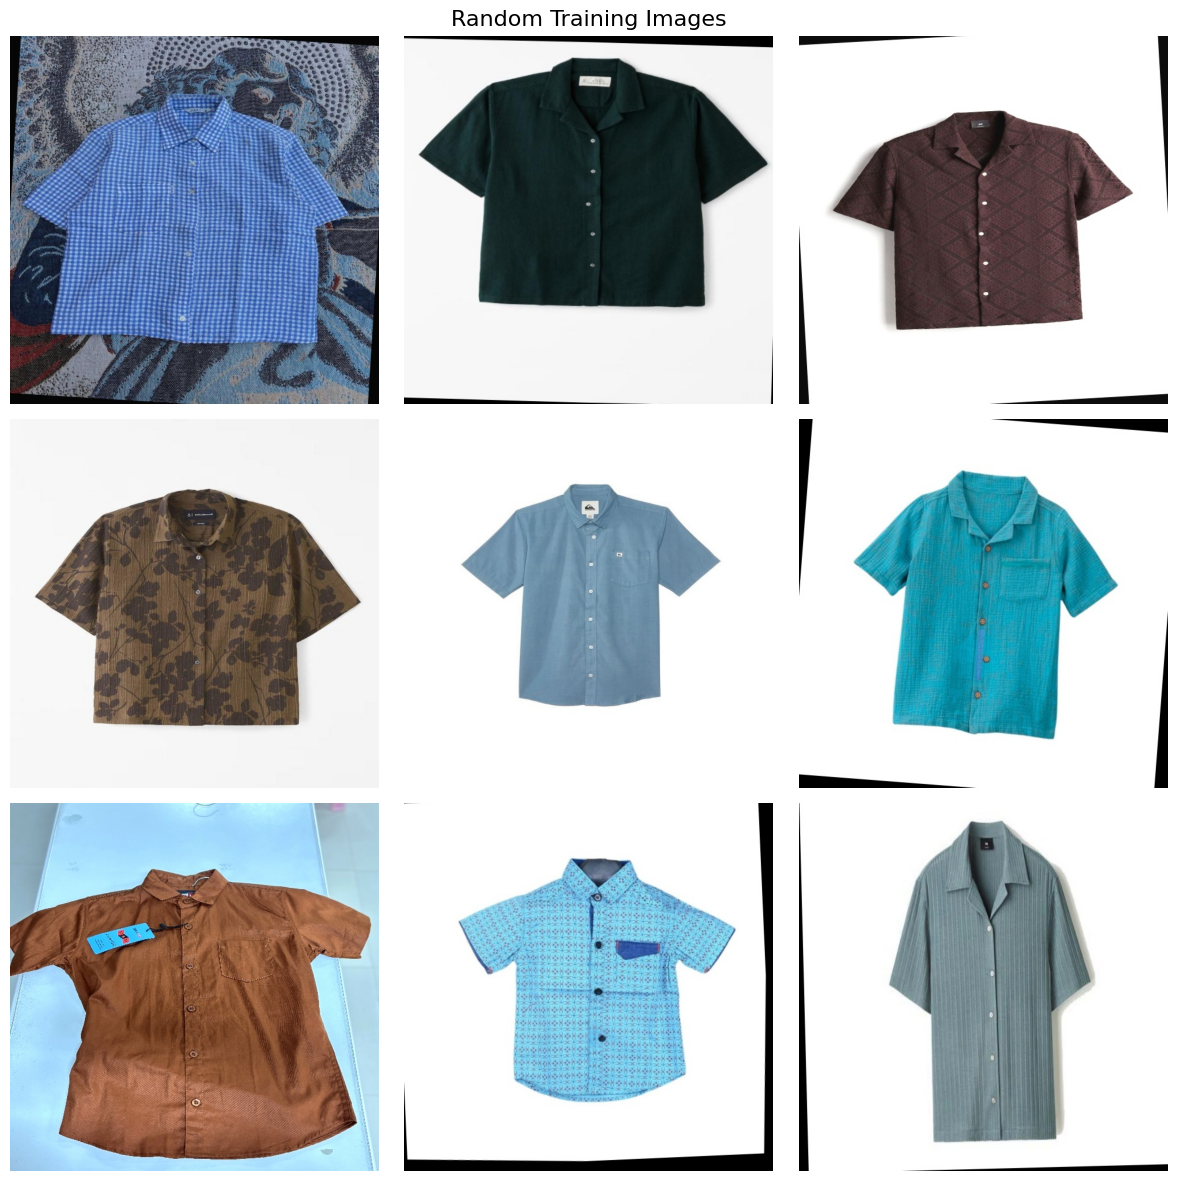

In [16]:
# ============================================================
# Display Sample Training Images
# ============================================================

import random
import matplotlib.pyplot as plt
import cv2

sample_images = random.sample(train_images, min(9, len(train_images)))

plt.figure(figsize=(12,12))

for i, img_path in enumerate(sample_images):

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Random Training Images", fontsize=16)
plt.tight_layout()
plt.show()

# 10. Visualize YOLO Bounding Box Annotations

## Purpose

Before training the YOLOv11 model, it is important to verify that the
bounding box annotations are correctly positioned and assigned to the
appropriate object classes.

This section randomly selects annotated training images and overlays
their bounding boxes with class labels for visual inspection.

This helps identify annotation errors before model training begins.

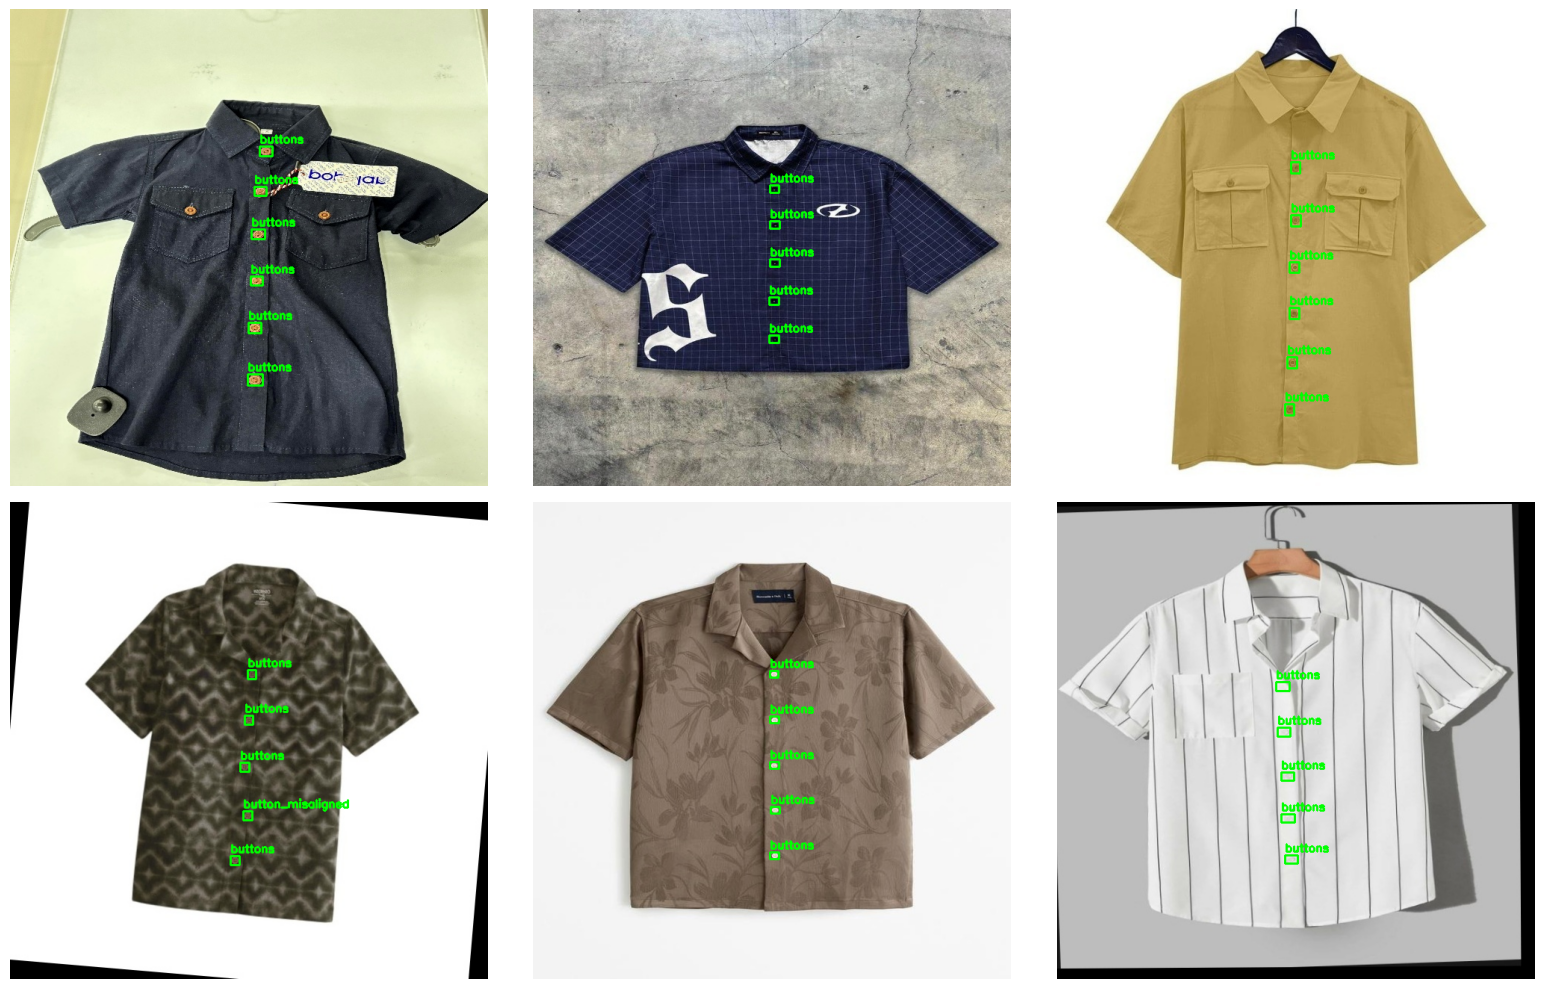

In [17]:
# ============================================================
# Display YOLO Bounding Boxes
# ============================================================

import os
import cv2
import random
import matplotlib.pyplot as plt

# Class names (must match data.yaml)
CLASS_NAMES = [
    "button_misaligned",
    "buttons",
    "missing_button_gap"
]

# Image and label directories
IMAGE_DIR = os.path.join(DATASET_PATH, "train/images")
LABEL_DIR = os.path.join(DATASET_PATH, "train/labels")

# Randomly select images
image_files = random.sample(os.listdir(IMAGE_DIR), min(6, len(os.listdir(IMAGE_DIR))))

plt.figure(figsize=(16,10))

for i, image_name in enumerate(image_files):

    image_path = os.path.join(IMAGE_DIR, image_name)

    label_path = os.path.join(
        LABEL_DIR,
        os.path.splitext(image_name)[0] + ".txt"
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            labels = f.readlines()

            for label in labels:

                cls, x, y, bw, bh = map(float, label.split())

                x = x * w
                y = y * h
                bw = bw * w
                bh = bh * h

                xmin = int(x - bw/2)
                ymin = int(y - bh/2)
                xmax = int(x + bw/2)
                ymax = int(y + bh/2)

                color = (0,255,0)

                cv2.rectangle(
                    image,
                    (xmin,ymin),
                    (xmax,ymax),
                    color,
                    2
                )

                cv2.putText(
                    image,
                    CLASS_NAMES[int(cls)],
                    (xmin,max(20,ymin-5)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    2
                )

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import yaml
import os

yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data["names"])

['button_misaligned', 'buttons', 'missing_button_gap']


# 11. Train YOLOv11 Object Detection Model

## Purpose

This section trains the YOLOv11 object detection model to identify three
types of button-related objects:

- buttons
- button_misaligned
- missing_button_gap

The YOLOv11 Nano (YOLOv11n) model is selected because it provides a good
balance between computational efficiency and detection performance,
making it suitable for relatively small datasets.

Several training parameters such as early stopping, image caching and
automatic optimizer selection are enabled to improve training
performance and reduce overfitting.

In [19]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "data.yaml" in files:
        print(os.path.join(root, "data.yaml"))

In [20]:
# ============================================================
# Train YOLOv11 Model
# ============================================================

from ultralytics import YOLO

# Load pretrained YOLOv11 Nano model
model = YOLO("yolo11n.pt")

# Path to data.yaml
yaml_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/data.yaml"

# Train model
results = model.train(

    # Dataset
    data=yaml_path,

    # Training
    epochs=100,
    imgsz=640,
    batch=16,

    # Hardware
    device=0,

    # Performance
    cache=True,
    workers=2,

    # Save results
    project="results",
    name="YOLOv11_Button_Defect",

    # Early stopping
    patience=20,

    # Automatically select optimizer
    optimizer="auto",

    # Save outputs
    save=True,
    plots=True,

    # Deterministic training
    seed=42,

    verbose=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, m

# Part II – Hybrid AI-Based Garment Defect Detection System

## Overview

The previous sections focused on training and evaluating the YOLOv11
object detection model.

This section extends the system by integrating OpenCV-based geometric
verification with YOLO detections.

The purpose of the hybrid framework is to improve the reliability of
garment defect inspection by verifying the spatial arrangement of
detected buttons instead of relying solely on neural network
predictions.

The hybrid inspection workflow consists of:

1. Loading the trained YOLOv11 model
2. Performing object detection
3. Extracting button locations
4. Geometric verification using OpenCV
5. Generating the final inspection report

# 11. Load the Trained YOLOv11 Model

## Purpose

The best-performing YOLOv11 model obtained during training is loaded
into memory.

This trained model will be used to detect:

- Normal buttons
- Misaligned buttons
- Missing button gaps

from unseen garment images.

In [9]:
# ============================================================
# Load Trained YOLOv11 Model
# ============================================================

from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/YOLO_Training/Garment_Defect_Detection/weights/best.pt"

model = YOLO(MODEL_PATH)

print("✅ Trained YOLOv11 model loaded successfully.")

✅ Trained YOLOv11 model loaded successfully.


# 12. Select a Test Image

## Purpose

A random image is selected from the test dataset to demonstrate the
performance of the trained YOLOv11 model.

Selecting random images enables quick testing of multiple garments
without modifying the notebook.

In [22]:
# ============================================================
# Select Random Test Image
# ============================================================

import glob
import random

TEST_IMAGE_DIR = os.path.join(DATASET_PATH, "test/images")

test_images = glob.glob(os.path.join(TEST_IMAGE_DIR, "*"))

TEST_IMAGE = random.choice(test_images)

print("Selected Image:")
print(TEST_IMAGE)

Selected Image:
/content/drive/MyDrive/Dataset_GarmentDefectDetection/YoloModelDataset/SplitDataset/test/images/B724_jpg.rf.b143b4ca085e3152129b20876a37b6d4.jpg


# 13. Perform Object Detection

## Purpose

The selected garment image is analysed using the trained YOLOv11 model.

Detected objects are classified as:

- buttons
- button_misaligned
- missing_button_gap

Each detection includes:

- Bounding box coordinates
- Confidence score
- Class label

In [23]:
# ============================================================
# Perform YOLO Detection
# ============================================================

results = model.predict(

    source=TEST_IMAGE,

    imgsz=640,

    conf=0.35,          # Best confidence from F1 curve

    save=False,

    verbose=False
)

print("✅ Detection Completed")

✅ Detection Completed


# 14. Visualise Detection Results

## Purpose

The detected objects are displayed with their corresponding
bounding boxes and class labels.

This provides a visual confirmation of the model predictions before
geometric verification is performed.

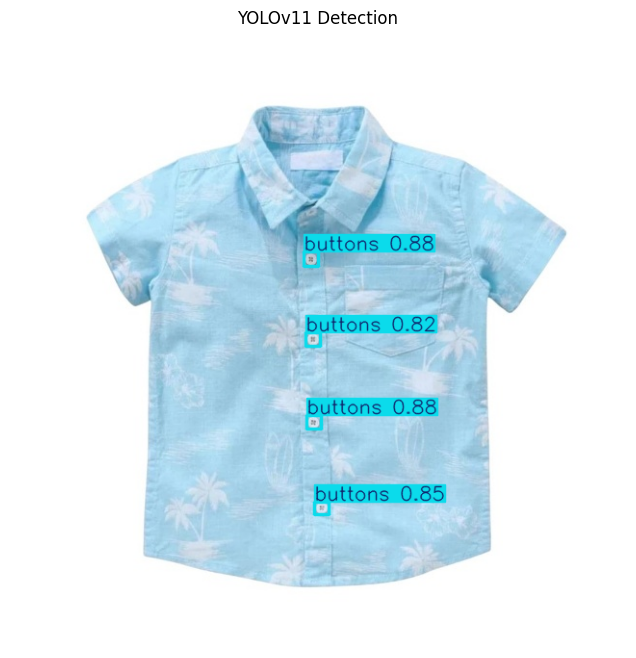

In [24]:
# ============================================================
# Display Detection Result
# ============================================================

import matplotlib.pyplot as plt

annotated = results[0].plot()

plt.figure(figsize=(8,8))

plt.imshow(annotated[:,:,::-1])

plt.axis("off")

plt.title("YOLOv11 Detection")

plt.show()

# 15. Extract Detection Information

## Purpose

The object detection results produced by YOLOv11 are converted into a
structured table.

For each detected object the following information is extracted:

- Object class
- Confidence score
- Bounding box coordinates
- Centre coordinates

The centre coordinates will be used during the OpenCV geometric
verification stage.

In [25]:
# ============================================================
# Extract Detection Information
# ============================================================

import pandas as pd

detections = []

for box in results[0].boxes:

    cls = int(box.cls[0])

    name = model.names[cls]

    conf = float(box.conf[0])

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    cx = (x1+x2)/2

    cy = (y1+y2)/2

    detections.append({

        "Class":name,

        "Confidence":round(conf,3),

        "X1":round(x1,1),

        "Y1":round(y1,1),

        "X2":round(x2,1),

        "Y2":round(y2,1),

        "Center_X":round(cx,1),

        "Center_Y":round(cy,1)

    })

detections_df = pd.DataFrame(detections)

display(detections_df)

,Class,Confidence,X1,Y1,X2,Y2,Center_X,Center_Y
0,buttons,0.880,308.1,398.9,323.1,412.7,315.6,405.8
1,buttons,0.876,305.2,229.0,320.3,243.5,312.7,236.2
2,buttons,0.851,316.4,488.2,331.6,501.1,324.0,494.7
3,buttons,0.822,307.0,312.6,322.9,326.1,314.9,319.3


# 16. Count Detected Objects

## Purpose

The total number of detected objects belonging to each class is
calculated.

This information provides a preliminary assessment of garment defects
before geometric verification.

In [26]:
# ============================================================
# Count Detected Objects
# ============================================================

object_counts = detections_df["Class"].value_counts()

print("Detected Objects\n")

print(object_counts)

Detected Objects

Class
buttons    4
Name: count, dtype: int64


In [27]:
# ============================================================
# Separate Button Categories
# ============================================================

normal_buttons = detections_df[
    detections_df["Class"]=="buttons"
].copy()

misaligned_buttons = detections_df[
    detections_df["Class"]=="button_misaligned"
].copy()

missing_buttons = detections_df[
    detections_df["Class"]=="missing_button_gap"
].copy()

print(f"Normal Buttons      : {len(normal_buttons)}")

print(f"Misaligned Buttons  : {len(misaligned_buttons)}")

print(f"Missing Button Gaps : {len(missing_buttons)}")

Normal Buttons      : 4
Misaligned Buttons  : 0
Missing Button Gaps : 0


# Part III – OpenCV Geometric Verification

## Overview

Although YOLOv11 effectively detects visible buttons and misaligned buttons,
it may fail to detect missing button locations because a missing button is
defined by the absence of an object rather than the presence of one.

To address this limitation, an OpenCV-based geometric verification module
is introduced.

The module analyses the spatial arrangement of detected button centres to:

- Verify button alignment
- Detect abnormal spacing between adjacent buttons
- Infer missing button locations
- Produce a final hybrid inspection result

This combines deep learning with deterministic geometric reasoning,
improving the robustness of garment defect detection.

# 18. Extract Visible Button Centres

## Purpose

Both normal buttons and misaligned buttons represent visible garment
buttons.

Their centre coordinates are extracted and combined into a single list
for geometric analysis.

Missing button locations are excluded because they do not correspond to
visible objects.

In [28]:
# ============================================================
# Combine Visible Buttons
# ============================================================

visible_buttons = pd.concat(
    [normal_buttons, misaligned_buttons],
    ignore_index=True
)

print(f"Visible Buttons Detected : {len(visible_buttons)}")

display(visible_buttons)

Visible Buttons Detected : 4


,Class,Confidence,X1,Y1,X2,Y2,Center_X,Center_Y
0,buttons,0.880,308.1,398.9,323.1,412.7,315.6,405.8
1,buttons,0.876,305.2,229.0,320.3,243.5,312.7,236.2
2,buttons,0.851,316.4,488.2,331.6,501.1,324.0,494.7
3,buttons,0.822,307.0,312.6,322.9,326.1,314.9,319.3


# 19. Sort Buttons by Vertical Position

## Purpose

Detected buttons are sorted according to their vertical centre
coordinates.

This establishes the natural top-to-bottom ordering required for spacing
analysis.

In [29]:
# ============================================================
# Sort Buttons
# ============================================================

visible_buttons = visible_buttons.sort_values(
    by="Center_Y"
).reset_index(drop=True)

visible_buttons["Button_ID"] = range(
    1,
    len(visible_buttons)+1
)

display(visible_buttons)

,Class,Confidence,X1,Y1,X2,Y2,Center_X,Center_Y,Button_ID
0,buttons,0.876,305.2,229.0,320.3,243.5,312.7,236.2,1
1,buttons,0.822,307.0,312.6,322.9,326.1,314.9,319.3,2
2,buttons,0.880,308.1,398.9,323.1,412.7,315.6,405.8,3
3,buttons,0.851,316.4,488.2,331.6,501.1,324.0,494.7,4


# 20. Calculate Vertical Button Spacing

## Purpose

The vertical distance between consecutive buttons is calculated.

Large spacing between adjacent buttons may indicate the presence of a
missing button.

In [30]:
# ============================================================
# Calculate Vertical Spacing
# ============================================================

button_gaps = []

for i in range(len(visible_buttons)-1):

    gap = (
        visible_buttons.loc[i+1,"Center_Y"]
        -
        visible_buttons.loc[i,"Center_Y"]
    )

    button_gaps.append(gap)

gap_df = pd.DataFrame({

    "Between": [

        f"Button {i+1} → Button {i+2}"

        for i in range(len(button_gaps))

    ],

    "Gap(px)": button_gaps

})

display(gap_df)

,Between,Gap(px)
0,Button 1 → Button 2,83.1
1,Button 2 → Button 3,86.5
2,Button 3 → Button 4,88.9


# 21. Estimate Normal Button Spacing

## Purpose

The median vertical spacing between adjacent buttons is used as the
reference spacing.

The median is preferred because it is less sensitive to unusually large
gaps caused by missing buttons.

In [31]:
# ============================================================
# Estimate Normal Spacing
# ============================================================

import numpy as np

expected_gap = np.median(button_gaps)

print(f"Expected Button Spacing : {expected_gap:.2f} pixels")

Expected Button Spacing : 86.50 pixels


# 22. Detect Abnormally Large Gaps

## Purpose

Each vertical spacing value is compared with the expected spacing.

If the spacing exceeds a predefined threshold, the gap is considered to
represent a potential missing button location.

In [32]:
# ============================================================
# Detect Large Gaps
# ============================================================

THRESHOLD = 1.6

large_gaps = []

for i, gap in enumerate(button_gaps):

    if gap > expected_gap * THRESHOLD:

        large_gaps.append(i)

print("Large Gap Locations")

print(large_gaps)

Large Gap Locations
[]


# 23. Estimate Missing Button Locations

## Purpose

After detecting the visible buttons, the OpenCV verification module
analyses the vertical spacing between consecutive buttons.

If a spacing value is significantly larger than the expected button
spacing, the algorithm estimates that one or more buttons are missing.

The estimated missing button locations are calculated using the midpoint
between neighbouring buttons.

Unlike conventional object detection, this approach does not rely solely
on the detection of a missing button class but instead infers missing
button locations using geometric reasoning.

In [33]:
# ============================================================
# Estimate Missing Button Locations
# ============================================================

estimated_missing_buttons = []

# Threshold multiplier
THRESHOLD = 1.6

for idx, gap in enumerate(button_gaps):

    # Number of expected button intervals
    estimated_intervals = round(gap / expected_gap)

    # If interval > 1, missing button(s) exist
    if estimated_intervals > 1:

        upper = visible_buttons.loc[idx]
        lower = visible_buttons.loc[idx + 1]

        for i in range(1, estimated_intervals):

            ratio = i / estimated_intervals

            estimated_x = upper["Center_X"] + (
                lower["Center_X"] - upper["Center_X"]
            ) * ratio

            estimated_y = upper["Center_Y"] + (
                lower["Center_Y"] - upper["Center_Y"]
            ) * ratio

            estimated_missing_buttons.append({

                "Center_X": estimated_x,

                "Center_Y": estimated_y

            })

estimated_missing_df = pd.DataFrame(estimated_missing_buttons)

print(f"Estimated Missing Buttons : {len(estimated_missing_df)}")

display(estimated_missing_df)

Estimated Missing Buttons : 0


""


# 24. Visualise Estimated Missing Button

## Purpose

The estimated missing button location obtained from spacing analysis is
drawn on the garment image.

Red circles indicate inferred missing button positions.

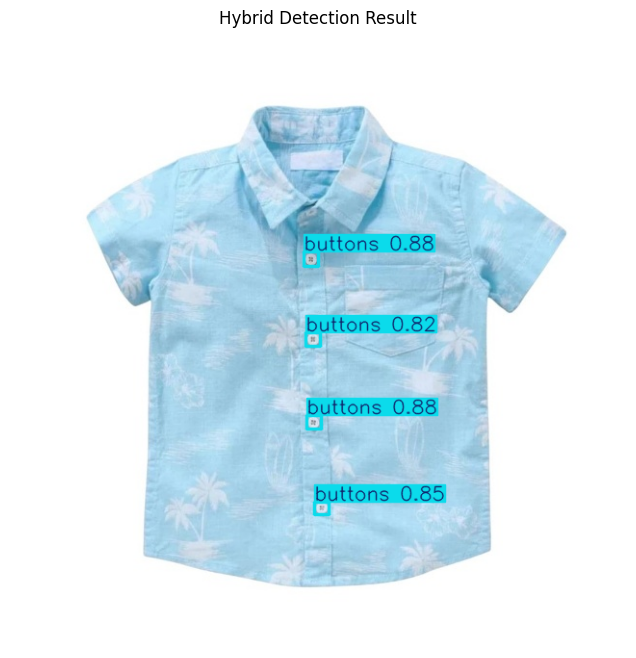

In [34]:
# ============================================================
# Draw Estimated Missing Button
# ============================================================

import cv2
import matplotlib.pyplot as plt

image = cv2.imread(TEST_IMAGE)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw YOLO detections
image = results[0].plot()[:, :, ::-1]

# Draw estimated missing buttons
for _, row in estimated_missing_df.iterrows():

    cv2.circle(
        image,
        (int(row["Center_X"]), int(row["Center_Y"])),
        15,
        (255, 0, 0),   # Red
        3
    )

    cv2.putText(
        image,
        "Estimated Missing",
        (int(row["Center_X"]) + 10, int(row["Center_Y"])),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Hybrid Detection Result")
plt.show()

# 25. Verify Button Alignment

## Purpose

The horizontal position of every visible button is analysed.

The median horizontal coordinate is used as the reference button line.

Buttons whose horizontal deviation exceeds a predefined threshold are
identified as potentially misaligned.

In [35]:
# ============================================================
# Verify Button Alignment
# ============================================================

reference_x = visible_buttons["Center_X"].median()

ALIGNMENT_THRESHOLD = 20  # pixels

alignment_results = []

for _, row in visible_buttons.iterrows():

    deviation = abs(row["Center_X"] - reference_x)

    alignment_results.append({

        "Button_ID": row["Button_ID"],
        "Deviation(px)": round(deviation,1),
        "Aligned": deviation <= ALIGNMENT_THRESHOLD

    })

alignment_df = pd.DataFrame(alignment_results)

display(alignment_df)

,Button_ID,Deviation(px),Aligned
0,1,2.6,True
1,2,0.4,True
2,3,0.4,True
3,4,8.8,True


# Part IV – OpenCV Alignment Verification

## Overview

This section performs geometric verification of button alignment using
OpenCV and linear regression.

While YOLOv11 predicts whether a button is misaligned, the OpenCV module
independently evaluates the spatial arrangement of detected button
centres.

A reference button line is estimated using linear regression, allowing
the system to calculate the horizontal deviation of each detected button.
This provides an additional level of verification before the final
hybrid decision is made.

# 26. Estimate the Reference Button Line

## Purpose

The centre coordinates of all visible buttons are used to estimate the
expected button alignment line.

Linear regression is employed to model the relationship between the
vertical and horizontal coordinates of the detected button centres.

The fitted regression line represents the expected alignment of a
correctly stitched button row.

In [36]:
# ============================================================
# Estimate Reference Button Line using Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np

# Use Y as input because buttons are arranged vertically
X = visible_buttons["Center_Y"].values.reshape(-1,1)

# X-coordinate is the value we want to predict
y = visible_buttons["Center_X"].values

# Fit regression model
regressor = LinearRegression()

regressor.fit(X, y)

print("="*60)
print("REFERENCE BUTTON LINE")
print("="*60)

print(f"Slope      : {regressor.coef_[0]:.4f}")

print(f"Intercept  : {regressor.intercept_:.2f}")

REFERENCE BUTTON LINE
Slope      : 0.0404
Intercept  : 302.11


# 27. Predict Expected Button Positions

## Purpose

The fitted regression model is used to estimate the expected horizontal
position of each detected button.

These predicted positions represent the ideal alignment line and are
later compared with the actual detected button positions.

In [37]:
# ============================================================
# Predict Expected X Coordinate
# ============================================================

visible_buttons["Predicted_X"] = regressor.predict(X)

display(visible_buttons)

,Class,Confidence,X1,Y1,X2,Y2,Center_X,Center_Y,Button_ID,Predicted_X
0,buttons,0.876,305.2,229.0,320.3,243.5,312.7,236.2,1,311.642041
1,buttons,0.822,307.0,312.6,322.9,326.1,314.9,319.3,2,314.995925
2,buttons,0.880,308.1,398.9,323.1,412.7,315.6,405.8,3,318.487032
3,buttons,0.851,316.4,488.2,331.6,501.1,324.0,494.7,4,322.075002


# 28. Calculate Horizontal Deviations

## Purpose

The horizontal deviation of each detected button is calculated as the
absolute difference between its actual horizontal position and the
predicted position obtained from the regression model.

Buttons with large deviations are considered potential alignment
defects.

In [38]:
# ============================================================
# Calculate Horizontal Deviations
# ============================================================

visible_buttons["Deviation"] = abs(

    visible_buttons["Center_X"]

    -

    visible_buttons["Predicted_X"]

)

display(

    visible_buttons[

        [

            "Button_ID",

            "Center_X",

            "Predicted_X",

            "Deviation"

        ]

    ]

)

,Button_ID,Center_X,Predicted_X,Deviation
0,1,312.7,311.642041,1.057959
1,2,314.9,314.995925,0.095925
2,3,315.6,318.487032,2.887032
3,4,324.0,322.075002,1.924998


# 29. Verify Button Alignment

## Purpose

Each detected button is compared with the estimated reference button
line.

Buttons whose horizontal deviation exceeds the predefined threshold are
classified as geometrically misaligned.

In [39]:
# ============================================================
# Verify Alignment
# ============================================================

ALIGNMENT_THRESHOLD = 20

visible_buttons["OpenCV_Result"] = np.where(

    visible_buttons["Deviation"] > ALIGNMENT_THRESHOLD,

    "Misaligned",

    "Aligned"

)

display(

    visible_buttons[

        [

            "Button_ID",

            "Deviation",

            "OpenCV_Result"

        ]

    ]

)

,Button_ID,Deviation,OpenCV_Result
0,1,1.057959,Aligned
1,2,0.095925,Aligned
2,3,2.887032,Aligned
3,4,1.924998,Aligned


# 30. Compare YOLO and OpenCV Results

## Purpose

The alignment predictions generated by YOLOv11 are compared with the
geometric verification results obtained from OpenCV.

Agreement between both approaches increases confidence in the final
inspection decision, while disagreement identifies cases that may
require further review.

In [40]:
# ============================================================
# Compare YOLO and OpenCV
# ============================================================

opencv_misaligned = visible_buttons[
    visible_buttons["OpenCV_Result"] == "Misaligned"
]

print("="*60)
print("ALIGNMENT COMPARISON")
print("="*60)

print(f"YOLO Misaligned Buttons   : {len(misaligned_buttons)}")

print(f"OpenCV Misaligned Buttons : {len(opencv_misaligned)}")

if len(misaligned_buttons) == len(opencv_misaligned):
    print("\n✅ Both methods agree.")

elif len(misaligned_buttons) > len(opencv_misaligned):
    print("\n⚠ YOLO detected more misaligned buttons than OpenCV.")

else:
    print("\n⚠ OpenCV detected additional alignment deviations.")

ALIGNMENT COMPARISON
YOLO Misaligned Buttons   : 0
OpenCV Misaligned Buttons : 0

✅ Both methods agree.


# Part V – Hybrid Decision Engine

## Overview

This section combines the predictions produced by the YOLOv11 object
detection model with the geometric verification results obtained from
OpenCV.

Rather than relying exclusively on either method, a decision fusion
strategy is adopted.

YOLOv11 serves as the primary decision-making component, while OpenCV
acts as a verification module to improve robustness.

The final inspection result is therefore based on the combined evidence
from both techniques.

# 31. Hybrid Decision Fusion

## Purpose

A rule-based decision fusion strategy is used to combine the outputs of
YOLOv11 and OpenCV.

The YOLOv11 predictions are treated as the primary inspection evidence,
while OpenCV contributes additional geometric verification.

This approach increases inspection reliability without allowing the
verification module to override high-confidence object detections.

In [41]:
# ============================================================
# Hybrid Decision Fusion
# ============================================================

decision = {
    "Misaligned": {
        "status": False,
        "confidence": "None",
        "source": ""
    },
    "Missing": {
        "status": False,
        "confidence": "None",
        "source": ""
    }
}

# -------------------------------------------------
# MISALIGNED BUTTON
# -------------------------------------------------

if len(misaligned_buttons) > 0:

    decision["Misaligned"] = {
        "status": True,
        "confidence": "High",
        "source": "YOLO Detection"
    }

elif len(opencv_misaligned) > 0:

    decision["Misaligned"] = {
        "status": True,
        "confidence": "Medium",
        "source": "OpenCV Verification"
    }

# -------------------------------------------------
# MISSING BUTTON
# -------------------------------------------------

if len(missing_buttons) > 0:

    decision["Missing"] = {
        "status": True,
        "confidence": "High",
        "source": "YOLO Detection"
    }

elif len(estimated_missing_df) > 0:

    decision["Missing"] = {
        "status": True,
        "confidence": "Medium",
        "source": "OpenCV Spacing Analysis"
    }

print("Decision fusion completed.")

Decision fusion completed.


In [42]:
# ============================================================
# Generate Inspection Summary
# ============================================================

inspection_summary = []

if decision["Misaligned"]["status"]:
    inspection_summary.append(
        f"Misaligned Button ({decision['Misaligned']['confidence']})"
    )

if decision["Missing"]["status"]:
    inspection_summary.append(
        f"Missing Button ({decision['Missing']['confidence']})"
    )

if len(inspection_summary) == 0:
    final_result = "PASS"
else:
    final_result = "FAIL"

print("=" * 70)
print("GARMENT INSPECTION SUMMARY")
print("=" * 70)

print(f"Visible Buttons : {len(visible_buttons)}")

print(f"YOLO Misaligned : {len(misaligned_buttons)}")

print(f"YOLO Missing Gap : {len(missing_buttons)}")

print(f"OpenCV Missing Estimate : {len(estimated_missing_df)}")

print("-" * 70)

print("Inspection Result :", final_result)

if inspection_summary:

    print("\nDetected Defects:")

    for defect in inspection_summary:

        print("•", defect)

else:

    print("\nNo garment defects detected.")

print("=" * 70)

GARMENT INSPECTION SUMMARY
Visible Buttons : 4
YOLO Misaligned : 0
YOLO Missing Gap : 0
OpenCV Missing Estimate : 0
----------------------------------------------------------------------
Inspection Result : PASS

No garment defects detected.


# 33. Visual Hybrid Inspection Dashboard

## Purpose

This section presents the final output of the proposed hybrid garment
inspection system.

The dashboard combines the predictions generated by YOLOv11 with the
OpenCV geometric verification results.

Detected buttons, estimated missing button locations and the fitted
reference alignment line are visualised together with an inspection
summary, providing an intuitive representation of the final inspection
decision.

In [44]:
# ============================================================
# Hybrid Inspection Dashboard
# ============================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load original image
image = cv2.imread(TEST_IMAGE)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw YOLO detections first
dashboard = results[0].plot()[:, :, ::-1].copy()

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
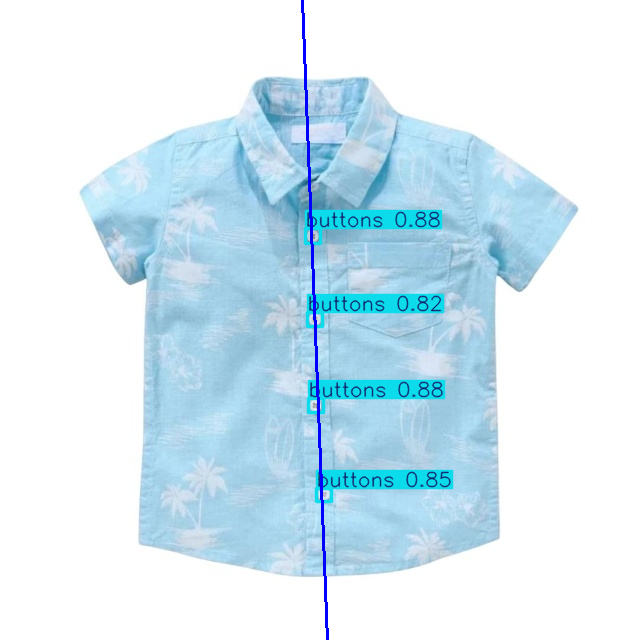

In [45]:
# ============================================================
# Draw Regression Line
# ============================================================

height, width = dashboard.shape[:2]

y_top = 0
y_bottom = height

x_top = regressor.predict(np.array([[y_top]]))[0]
x_bottom = regressor.predict(np.array([[y_bottom]]))[0]

cv2.line(
    dashboard,
    (int(x_top), int(y_top)),
    (int(x_bottom), int(y_bottom)),
    (0, 0, 255),      # Blue in displayed RGB image after plotting
    2
)

In [46]:
# ============================================================
# Draw Estimated Missing Buttons
# ============================================================

for _, row in estimated_missing_df.iterrows():

    cv2.circle(
        dashboard,
        (int(row["Center_X"]), int(row["Center_Y"])),
        14,
        (255,0,0),
        3
    )

    cv2.putText(
        dashboard,
        "Missing",
        (int(row["Center_X"])+10,
         int(row["Center_Y"])-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

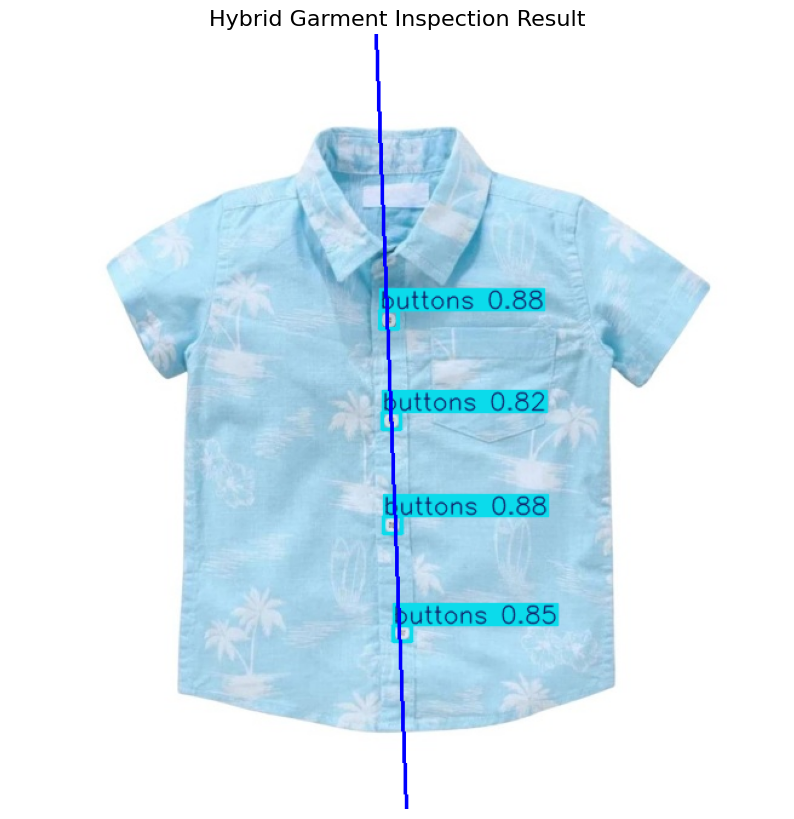

In [47]:
# ============================================================
# Display Dashboard
# ============================================================

plt.figure(figsize=(10,12))

plt.imshow(dashboard)

plt.axis("off")

plt.title("Hybrid Garment Inspection Result", fontsize=16)

plt.show()

In [48]:
# ============================================================
# Final Inspection Summary
# ============================================================

print("="*70)
print("        HYBRID GARMENT INSPECTION REPORT")
print("="*70)

print("\nYOLO DETECTION")
print("-"*70)
print(f"Visible Buttons           : {len(visible_buttons)}")
print(f"Misaligned Buttons        : {len(misaligned_buttons)}")
print(f"Missing Button Detections : {len(missing_buttons)}")

print("\nOpenCV VERIFICATION")
print("-"*70)
print(f"Reference Spacing         : {expected_gap:.1f} px")
print(f"Estimated Missing Buttons : {len(estimated_missing_df)}")
print(f"Alignment Deviations      : {len(opencv_misaligned)}")

print("\nHYBRID DECISION")
print("-"*70)

if decision["Misaligned"]["status"]:
    print(f"✔ Misaligned Button ({decision['Misaligned']['confidence']} Confidence)")

if decision["Missing"]["status"]:
    print(f"⚠ Missing Button ({decision['Missing']['confidence']} Confidence)")

if not decision["Misaligned"]["status"] and not decision["Missing"]["status"]:
    print("✅ No defects detected")

print("\nFINAL RESULT")
print("-"*70)

if decision["Misaligned"]["status"] or decision["Missing"]["status"]:
    print("❌ FAIL")
else:
    print("✅ PASS")

print("="*70)

        HYBRID GARMENT INSPECTION REPORT

YOLO DETECTION
----------------------------------------------------------------------
Visible Buttons           : 4
Misaligned Buttons        : 0
Missing Button Detections : 0

OpenCV VERIFICATION
----------------------------------------------------------------------
Reference Spacing         : 86.5 px
Estimated Missing Buttons : 0
Alignment Deviations      : 0

HYBRID DECISION
----------------------------------------------------------------------
✅ No defects detected

FINAL RESULT
----------------------------------------------------------------------
✅ PASS


# Part VI – Real-World Garment Inspection

## Overview

This section demonstrates the practical application of the proposed
Hybrid AI-Based Garment Defect Detection System.

Unlike the previous evaluation performed using labelled test data,
the images analysed in this section contain no annotations or ground
truth labels.

Each garment image is processed exactly as it would be in a real
manufacturing environment.

The trained YOLOv11 model performs object detection, after which
OpenCV verifies button spacing and alignment before the Hybrid
Decision Engine generates the final inspection report.

# Part VI – Real-World Garment Inspection

## 34. Upload a Garment Image

### Purpose

This section allows the user to upload a previously unseen garment image
for inspection.

Unlike the labelled test dataset used during model evaluation, the uploaded
image contains no annotation file.

The uploaded image is processed using the complete Hybrid AI-Based Garment
Defect Detection System.

In [10]:
# ============================================================
# Upload Real-World Garment Image
# ============================================================

from google.colab import files
import os

print("=" * 60)
print("Upload a Garment Image for Inspection")
print("=" * 60)

uploaded = files.upload()

TEST_IMAGE = next(iter(uploaded))

print("\nSelected Image:")
print(TEST_IMAGE)

Upload a Garment Image for Inspection


Saving B49.jpg to B49.jpg

Selected Image:
B49.jpg


# 35. Hybrid Garment Inspection

## Purpose

The uploaded garment image is analysed using the proposed Hybrid
AI-Based Garment Defect Detection System.

The inspection process consists of:

- YOLOv11 object detection
- Button counting
- Missing button verification
- Button alignment verification
- Hybrid decision fusion
- Final inspection dashboard

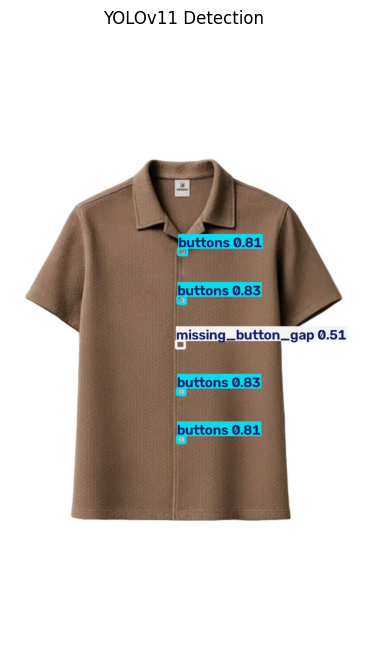

Detected Objects

Visible Buttons Detected : 4
Large Gap Locations
[1]
Estimated Missing Buttons : 1


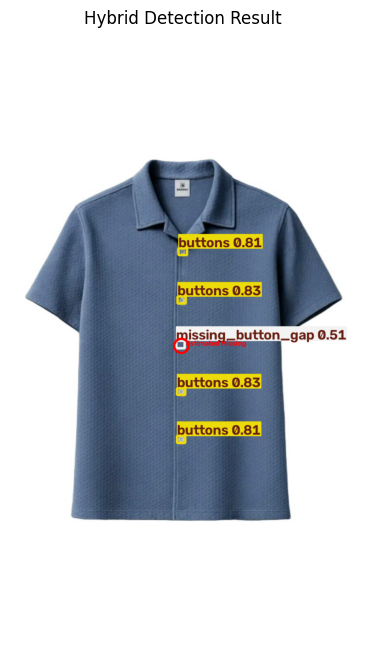


✅ Both methods agree.
        HYBRID GARMENT INSPECTION REPORT

YOLO DETECTION
----------------------------------------------------------------------
Visible Buttons           : 4
Misaligned Buttons        : 0
Missing Button Detections : 1

OpenCV VERIFICATION
----------------------------------------------------------------------
Reference Spacing         : 103.2 px
Estimated Missing Buttons : 1
Alignment Deviations      : 0

HYBRID DECISION
----------------------------------------------------------------------
⚠ Missing Button (High Confidence)

FINAL RESULT
----------------------------------------------------------------------
❌ FAIL


In [12]:
# ============================================================
# Perform YOLO Detection
# ============================================================

results = model.predict(

    source=TEST_IMAGE,

    imgsz=640,

    conf=0.35,          # Best confidence from F1 curve

    save=False,

    verbose=False
)

# ============================================================
# Display Detection Result
# ============================================================

import matplotlib.pyplot as plt

annotated = results[0].plot()

plt.figure(figsize=(8,8))

plt.imshow(annotated[:,:,::-1])

plt.axis("off")

plt.title("YOLOv11 Detection")

plt.show()

# ============================================================
# Extract Detection Information
# ============================================================

import pandas as pd

detections = []

for box in results[0].boxes:

    cls = int(box.cls[0])

    name = model.names[cls]

    conf = float(box.conf[0])

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    cx = (x1+x2)/2

    cy = (y1+y2)/2

    detections.append({

        "Class":name,

        "Confidence":round(conf,3),

        "X1":round(x1,1),

        "Y1":round(y1,1),

        "X2":round(x2,1),

        "Y2":round(y2,1),

        "Center_X":round(cx,1),

        "Center_Y":round(cy,1)

    })

detections_df = pd.DataFrame(detections)


# ============================================================
# Count Detected Objects
# ============================================================

object_counts = detections_df["Class"].value_counts()

print("Detected Objects\n")

# ============================================================
# Separate Button Categories
# ============================================================

normal_buttons = detections_df[
    detections_df["Class"]=="buttons"
].copy()

misaligned_buttons = detections_df[
    detections_df["Class"]=="button_misaligned"
].copy()

missing_buttons = detections_df[
    detections_df["Class"]=="missing_button_gap"
].copy()


# ============================================================
# Combine Visible Buttons
# ============================================================

visible_buttons = pd.concat(
    [normal_buttons, misaligned_buttons],
    ignore_index=True
)

print(f"Visible Buttons Detected : {len(visible_buttons)}")


# ============================================================
# Sort Buttons
# ============================================================

visible_buttons = visible_buttons.sort_values(
    by="Center_Y"
).reset_index(drop=True)

visible_buttons["Button_ID"] = range(
    1,
    len(visible_buttons)+1
)


# ============================================================
# Calculate Vertical Spacing
# ============================================================

button_gaps = []

for i in range(len(visible_buttons)-1):

    gap = (
        visible_buttons.loc[i+1,"Center_Y"]
        -
        visible_buttons.loc[i,"Center_Y"]
    )

    button_gaps.append(gap)

gap_df = pd.DataFrame({

    "Between": [

        f"Button {i+1} → Button {i+2}"

        for i in range(len(button_gaps))

    ],

    "Gap(px)": button_gaps

})


# ============================================================
# Estimate Normal Spacing
# ============================================================

import numpy as np

expected_gap = np.median(button_gaps)

# ============================================================
# Detect Large Gaps
# ============================================================

THRESHOLD = 1.6

large_gaps = []

for i, gap in enumerate(button_gaps):

    if gap > expected_gap * THRESHOLD:

        large_gaps.append(i)

print("Large Gap Locations")

print(large_gaps)


# ============================================================
# Estimate Missing Button Locations
# ============================================================

estimated_missing_buttons = []

# Threshold multiplier
THRESHOLD = 1.6

for idx, gap in enumerate(button_gaps):

    # Number of expected button intervals
    estimated_intervals = round(gap / expected_gap)

    # If interval > 1, missing button(s) exist
    if estimated_intervals > 1:

        upper = visible_buttons.loc[idx]
        lower = visible_buttons.loc[idx + 1]

        for i in range(1, estimated_intervals):

            ratio = i / estimated_intervals

            estimated_x = upper["Center_X"] + (
                lower["Center_X"] - upper["Center_X"]
            ) * ratio

            estimated_y = upper["Center_Y"] + (
                lower["Center_Y"] - upper["Center_Y"]
            ) * ratio

            estimated_missing_buttons.append({

                "Center_X": estimated_x,

                "Center_Y": estimated_y

            })

estimated_missing_df = pd.DataFrame(estimated_missing_buttons)

print(f"Estimated Missing Buttons : {len(estimated_missing_df)}")

# ============================================================
# Draw Estimated Missing Button
# ============================================================

import cv2
import matplotlib.pyplot as plt

image = cv2.imread(TEST_IMAGE)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw YOLO detections
image = results[0].plot()
image = np.ascontiguousarray(image)

# Draw estimated missing buttons
for _, row in estimated_missing_df.iterrows():

    cv2.circle(
        image,
        (int(row["Center_X"]), int(row["Center_Y"])),
        15,
        (255, 0, 0),   # Red
        3
    )

    cv2.putText(
        image,
        "Estimated Missing",
        (int(row["Center_X"]) + 10, int(row["Center_Y"])),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Hybrid Detection Result")
plt.show()

# ============================================================
# Verify Button Alignment
# ============================================================

reference_x = visible_buttons["Center_X"].median()

ALIGNMENT_THRESHOLD = 20  # pixels

alignment_results = []

for _, row in visible_buttons.iterrows():

    deviation = abs(row["Center_X"] - reference_x)

    alignment_results.append({

        "Button_ID": row["Button_ID"],
        "Deviation(px)": round(deviation,1),
        "Aligned": deviation <= ALIGNMENT_THRESHOLD

    })

alignment_df = pd.DataFrame(alignment_results)

# ============================================================
# Estimate Reference Button Line using Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np

# Use Y as input because buttons are arranged vertically
X = visible_buttons["Center_Y"].values.reshape(-1,1)

# X-coordinate is the value we want to predict
y = visible_buttons["Center_X"].values

# Fit regression model
regressor = LinearRegression()

regressor.fit(X, y)


#print(f"Slope      : {regressor.coef_[0]:.4f}")

#print(f"Intercept  : {regressor.intercept_:.2f}")

# ============================================================
# Predict Expected X Coordinate
# ============================================================

visible_buttons["Predicted_X"] = regressor.predict(X)

# Calculate deviation from the fitted reference line
visible_buttons["Deviation"] = abs(
    visible_buttons["Center_X"] -
    visible_buttons["Predicted_X"]
)

# ============================================================
# Verify Alignment
# ============================================================

ALIGNMENT_THRESHOLD = 20

visible_buttons["OpenCV_Result"] = np.where(

    visible_buttons["Deviation"] > ALIGNMENT_THRESHOLD,

    "Misaligned",

    "Aligned"

)



# ============================================================
# Compare YOLO and OpenCV
# ============================================================

opencv_misaligned = visible_buttons[
    visible_buttons["OpenCV_Result"] == "Misaligned"
]


#print(f"YOLO Misaligned Buttons   : {len(misaligned_buttons)}")

#print(f"OpenCV Misaligned Buttons : {len(opencv_misaligned)}")

if len(misaligned_buttons) == len(opencv_misaligned):
    print("\n✅ Both methods agree.")

elif len(misaligned_buttons) > len(opencv_misaligned):
    print("\n⚠ YOLO detected more misaligned buttons than OpenCV.")

else:
    print("\n⚠ OpenCV detected additional alignment deviations.")

# ============================================================
# Hybrid Decision Fusion
# ============================================================

decision = {
    "Misaligned": {
        "status": False,
        "confidence": "None",
        "source": ""
    },
    "Missing": {
        "status": False,
        "confidence": "None",
        "source": ""
    }
}

# -------------------------------------------------
# MISALIGNED BUTTON
# -------------------------------------------------

if len(misaligned_buttons) > 0:

    decision["Misaligned"] = {
        "status": True,
        "confidence": "High",
        "source": "YOLO Detection"
    }

elif len(opencv_misaligned) > 0:

    decision["Misaligned"] = {
        "status": True,
        "confidence": "Medium",
        "source": "OpenCV Verification"
    }

# -------------------------------------------------
# MISSING BUTTON
# -------------------------------------------------

if len(missing_buttons) > 0:

    decision["Missing"] = {
        "status": True,
        "confidence": "High",
        "source": "YOLO Detection"
    }

elif len(estimated_missing_df) > 0:

    decision["Missing"] = {
        "status": True,
        "confidence": "Medium",
        "source": "OpenCV Spacing Analysis"
    }

# ============================================================
# Final Inspection Summary
# ============================================================

print("="*70)
print("        HYBRID GARMENT INSPECTION REPORT")
print("="*70)

print("\nYOLO DETECTION")
print("-"*70)
print(f"Visible Buttons           : {len(visible_buttons)}")
print(f"Misaligned Buttons        : {len(misaligned_buttons)}")
print(f"Missing Button Detections : {len(missing_buttons)}")

print("\nOpenCV VERIFICATION")
print("-"*70)
print(f"Reference Spacing         : {expected_gap:.1f} px")
print(f"Estimated Missing Buttons : {len(estimated_missing_df)}")
print(f"Alignment Deviations      : {len(opencv_misaligned)}")

print("\nHYBRID DECISION")
print("-"*70)

if decision["Misaligned"]["status"]:
    print(f"✔ Misaligned Button ({decision['Misaligned']['confidence']} Confidence)")

if decision["Missing"]["status"]:
    print(f"⚠ Missing Button ({decision['Missing']['confidence']} Confidence)")

if not decision["Misaligned"]["status"] and not decision["Missing"]["status"]:
    print("✅ No defects detected")

print("\nFINAL RESULT")
print("-"*70)

if decision["Misaligned"]["status"] or decision["Missing"]["status"]:
    print("❌ FAIL")
else:
    print("✅ PASS")

print("="*70)
